In [3]:
import jax.numpy as jnp
import jax

mu0 = -1.
mu1 = 1.
sigma2 = 1.

OP_key = jax.random.PRNGKey(0)

def simulate(key, num_samples):
  key, subkey = jax.random.split(key)
  bers = jax.random.bernoulli(subkey, p=0.5, shape=(num_samples, ))
  means = jnp.where(bers, mu1, mu0)
  observations = means + sigma2 * jax.random.normal(key, shape=(num_samples, ))
  return observations

my_samples = simulate(OP_key, 10000)


(array([0.00051855, 0.        , 0.        , 0.00051855, 0.00207418,
        0.00414837, 0.00674109, 0.01088946, 0.0181491 , 0.03163125,
        0.04148366, 0.04822476, 0.07052214, 0.0917826 , 0.11874683,
        0.13793317, 0.164379  , 0.18097224, 0.18823211, 0.23127112,
        0.23904989, 0.25045729, 0.22660421, 0.25460628, 0.23853075,
        0.23282676, 0.24579038, 0.23956843, 0.24734602, 0.23593803,
        0.23645716, 0.19963987, 0.18512061, 0.1799356 , 0.13948864,
        0.12030247, 0.09489399, 0.09281958, 0.05444724, 0.04459488,
        0.02852005, 0.01659348, 0.01503781, 0.00829672, 0.005704  ,
        0.00103709, 0.00103709, 0.        , 0.00155564, 0.00103709]),
 array([-4.86273956, -4.66989231, -4.47704554, -4.28419828, -4.09135103,
        -3.89850402, -3.70565701, -3.51280975, -3.31996274, -3.12711573,
        -2.93426847, -2.74142146, -2.54857445, -2.3557272 , -2.16288018,
        -1.97003293, -1.77718592, -1.5843389 , -1.39149165, -1.19864464,
        -1.00579739, -0.81

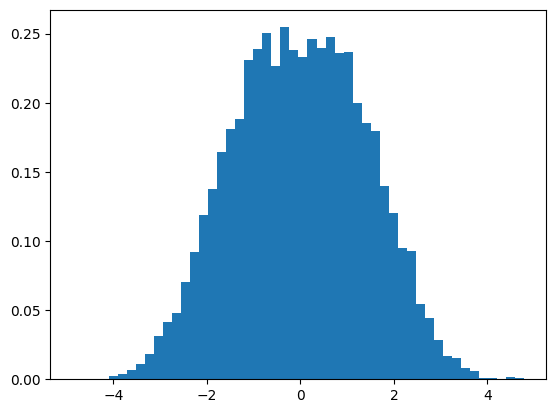

In [4]:
import matplotlib.pyplot as plt
plt.hist(my_samples, density=True, bins=50)

In [5]:
def log_proba_cond_zi(y, mus):
  r"""
  This is the (log) conditional probability
    p(Z_i = 0 \given y_i, (\mu_0, \mu_1))
  """
  mu0, mu1 = mus
  log_p0 = -0.5 * (y-mu0)**2
  log_p1 = -0.5 * (y-mu1)**2
  log_p_max = jax.lax.max(log_p0, log_p1)
  log_p = log_p0 - log_p_max - jnp.log((jnp.exp(log_p0-log_p_max)+jnp.exp(log_p1-log_p_max)))
  return log_p

"""
prior parameters on the mean parameters
"""
mean_prior = 0.
sigma_prior2 = 10**2

def mean_cov_posterior_on_mus(ys, zs):
  n = ys.shape[0]
  n1 = zs.sum()
  n0 = n - n1
  empirical_mean_0 = jnp.sum(ys * (zs==0))/jax.lax.max(n0, 1)
  empirical_mean_1 = jnp.sum(ys * (zs==1))/jax.lax.max(n1, 1)
  cond_sigmasq_mean_0 = 1 / (1/sigma_prior2 + n0 / sigma2)
  cond_sigmasq_mean_1 = 1 / (1/sigma_prior2 + n1 / sigma2)
  cond_mean_mean_0 = cond_sigmasq_mean_0 * (1/sigma_prior2 * mean_prior + n0/sigma2 * empirical_mean_0)
  cond_mean_mean_1 = cond_sigmasq_mean_1 * (1/sigma_prior2 * mean_prior + n1/sigma2 * empirical_mean_1)
  return jnp.array([cond_mean_mean_0, cond_mean_mean_1]), jnp.array([cond_sigmasq_mean_0, cond_sigmasq_mean_1])


def gibbs(key, num_samples, ys):
  key, subkey = jax.random.split(key)
  n = ys.shape[0]

  log_unifs = jnp.log(jax.random.uniform(subkey, shape=(num_samples, n)))

  key, subkey = jax.random.split(key)
  mus_init = (sigma_prior2 ** 0.5) * jax.random.normal(subkey, shape=(2, ))
  key, subkey = jax.random.split(key)

  zis_init = jax.random.bernoulli(subkey, p=0.5, shape=(n,))

  normals = jax.random.normal(key, shape=(num_samples, 2))


  seqs_mus = jnp.zeros(shape=(num_samples, 2))

  seqs_mus = seqs_mus.at[0].set(mus_init)

  def body(t, inps):
    seqs_mus, zis = inps
    prev_mus = seqs_mus.at[t-1].get()
    def inner_body(i, zis):
      """
      Updating each zis
      """
      log_p_zi = log_proba_cond_zi(ys.at[i].get(), prev_mus)
      chosen_zi = jax.lax.select(log_unifs.at[t-1, i].get()<=log_p_zi, False, True)
      zis = zis.at[i].set(chosen_zi)
      return zis
    zis = jax.lax.fori_loop(0, n, inner_body, jnp.zeros(shape=(n, ), dtype=bool))
    cond_means, cond_sigmasq = mean_cov_posterior_on_mus(ys, zis)
    mus_sampled = cond_means + cond_sigmasq ** 0.5 * normals.at[t-1].get()
    seqs_mus = seqs_mus.at[t].set(mus_sampled)
    return seqs_mus, zis
  seqs_mus, _ = jax.lax.fori_loop(1, num_samples, body, (seqs_mus, zis_init))
  return seqs_mus

In [13]:
res = gibbs(OP_key, 1000, my_samples)[100:]

(array([[  6.,  93., 333., 344., 116.,   8.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         

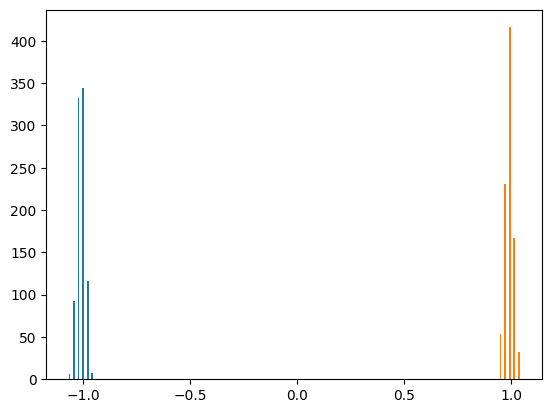

In [15]:
plt.hist(res, bins=100)